## Section 1 — Setup & Loading


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
from collections import Counter
import numpy as np


# Paths
DATA_PROCESSED = '../data/processed/'
FIGURES_PATH   = '../eda/figures/'
os.makedirs(FIGURES_PATH, exist_ok=True)

# Safe list parser
def safe_parse(val):
    try:
        return ast.literal_eval(val)
    except:
        return []

# Load processed files
movies = pd.read_csv(DATA_PROCESSED + 'movies.csv')

# Parse list columns back from string to actual lists
movies['genres_list']    = movies['genres_list'].apply(safe_parse)
movies['countries_list'] = movies['countries_list'].apply(safe_parse)
movies['companies_list'] = movies['companies_list'].apply(safe_parse)
movies['languages_list'] = movies['languages_list'].apply(safe_parse)
movies['top_cast']       = movies['top_cast'].apply(safe_parse)

print("movies shape:", movies.shape)
print("\nColumns:", movies.columns.tolist())

movies shape: (45697, 21)

Columns: ['budget', 'id', 'original_language', 'popularity', 'release_date', 'revenue', 'runtime', 'title', 'vote_average', 'vote_count', 'year', 'decade', 'genres_list', 'countries_list', 'companies_list', 'languages_list', 'director', 'top_cast', 'movielens_avg_rating', 'movielens_vote_count', 'ratings_list']


## Section 2 — Movies Overview

### 2.1 Movies per Decade


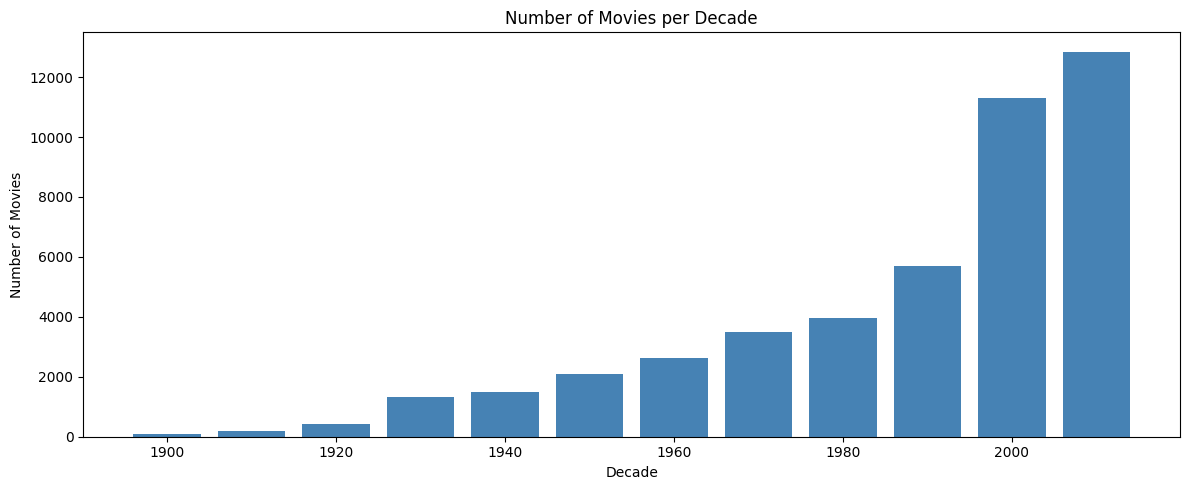

In [3]:
decade_counts = movies.dropna(subset=['decade'])
decade_counts = decade_counts[
    (decade_counts['decade'] >= 1900) &
    (decade_counts['decade'] <= 2010)
]
decade_grouped = decade_counts.groupby('decade').size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(decade_grouped.index, decade_grouped.values, color='steelblue', width=8)
ax.set_title('Number of Movies per Decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Movies')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'movies_per_decade.png', dpi=150)
plt.show()

### 2.2 Top Languages


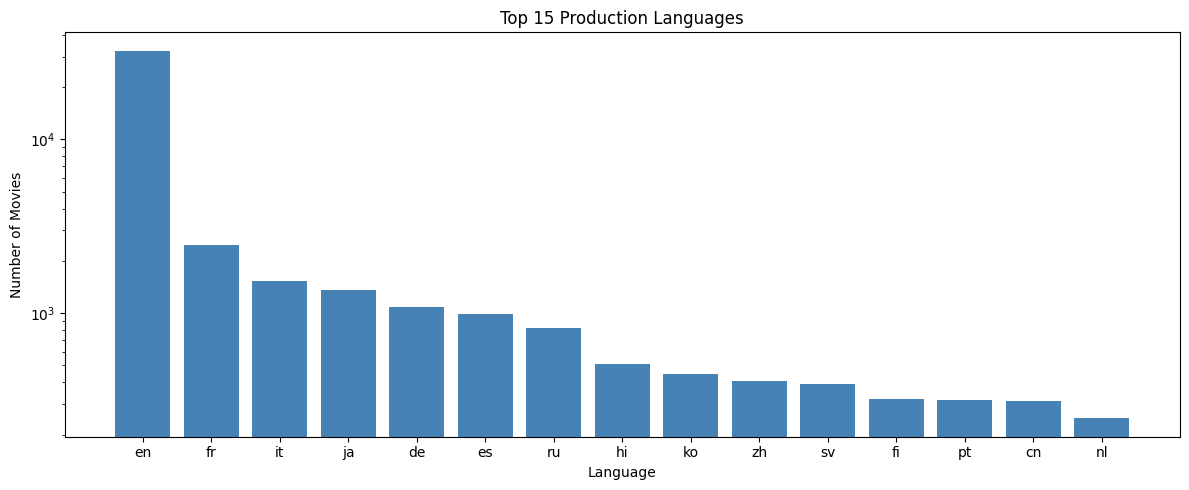

In [24]:
top_languages = movies['original_language'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_languages.index, top_languages.values, color='steelblue')
ax.set_yscale('log')
ax.set_title('Top 15 Production Languages')
ax.set_xlabel('Language')
ax.set_ylabel('Number of Movies')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'top_languages.png', dpi=150)
plt.show()

### 2.3 Top Production Countries


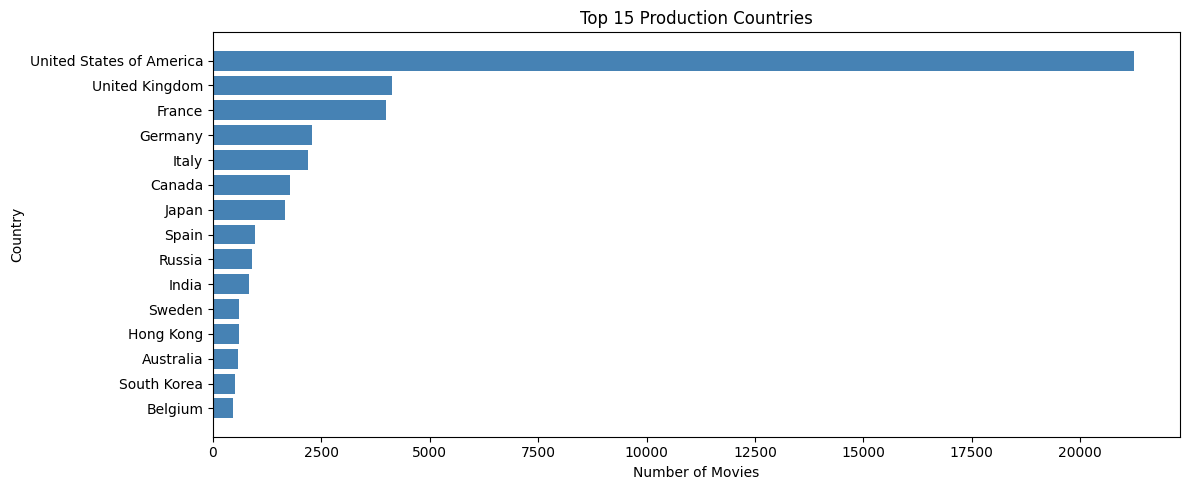

In [21]:
all_countries = [c for sublist in movies['countries_list'] for c in sublist]
country_counts = Counter(all_countries).most_common(15)
country_df = pd.DataFrame(country_counts, columns=['Country', 'Count'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(country_df['Country'][::-1], country_df['Count'][::-1], color='steelblue')
ax.set_title('Top 15 Production Countries')
ax.set_xlabel('Number of Movies')
ax.set_ylabel('Country')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'top_countries.png', dpi=150)
plt.show()

## Section 3 — Genre Analysis


### 3.1 Top 15 Genres


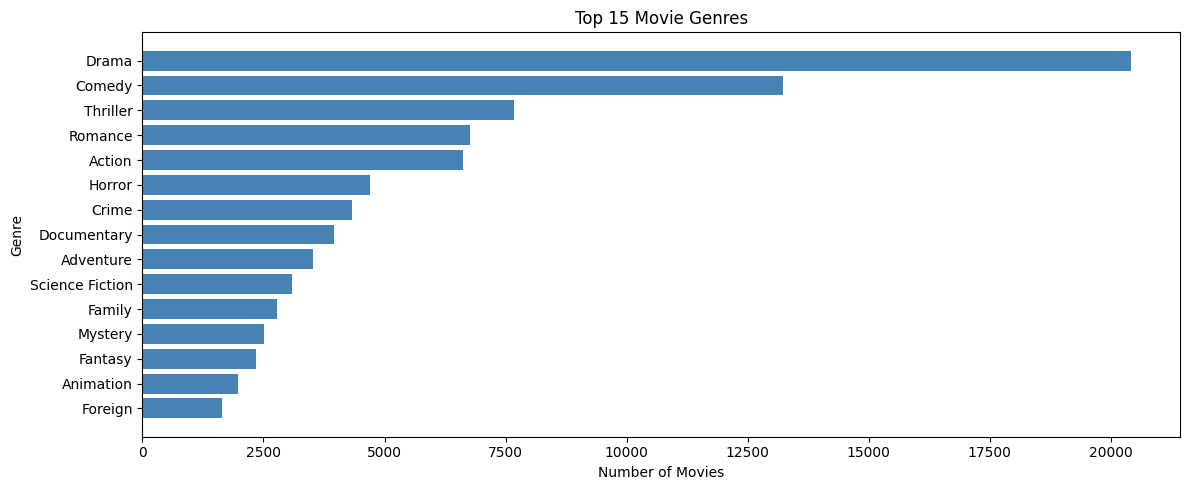

In [6]:
all_genres = [g for sublist in movies['genres_list'] for g in sublist]
genre_counts = Counter(all_genres).most_common(15)
genre_df = pd.DataFrame(genre_counts, columns=['Genre', 'Count'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(genre_df['Genre'][::-1], genre_df['Count'][::-1], color='steelblue')
ax.set_title('Top 15 Movie Genres')
ax.set_xlabel('Number of Movies')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'top_genres.png', dpi=150)
plt.show()

### 3.2 Genre Evolution over Decades

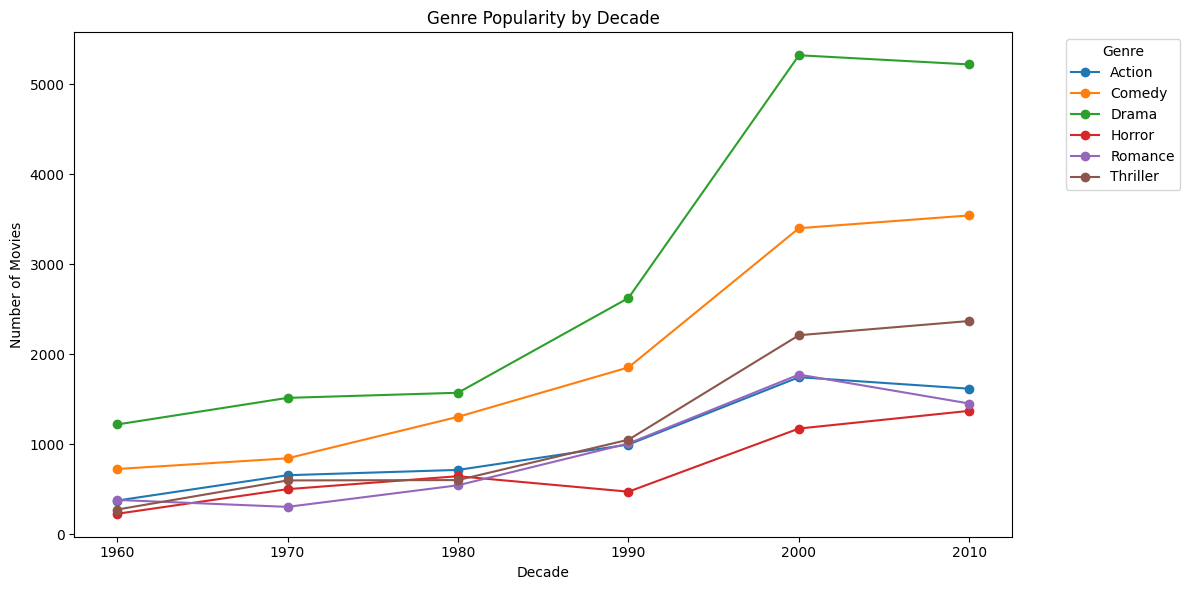

In [8]:
top_genres = [g for g, _ in Counter(all_genres).most_common(6)]

rows = []
for _, row in movies.dropna(subset=['decade']).iterrows():
    for genre in row['genres_list']:
        if genre in top_genres:
            rows.append({'decade': row['decade'], 'genre': genre})

genre_decade = pd.DataFrame(rows)
genre_decade = genre_decade[
    (genre_decade['decade'] >= 1960) &
    (genre_decade['decade'] <= 2010)
]
pivot = genre_decade.groupby(['decade', 'genre']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='line', marker='o', ax=ax)
ax.set_title('Genre Popularity by Decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Movies')
ax.legend(title='Genre', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'genre_evolution.png', dpi=150)
plt.show()

## Section 4 — Financial Analysis


### 4.1 Budget vs Revenue Scatter


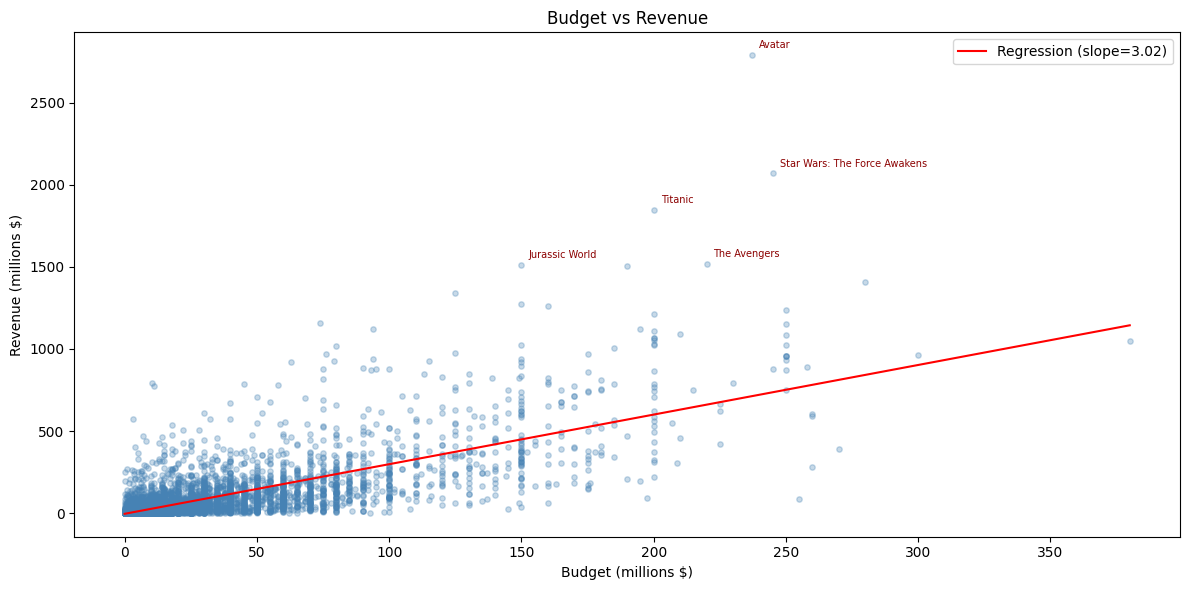

In [ ]:
movies_financial = movies[movies['budget'].notna() & movies['revenue'].notna()].copy()
movies_financial['roi'] = movies_financial['revenue'] / movies_financial['budget']

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(movies_financial['budget'] / 1e6, movies_financial['revenue'] / 1e6,
           alpha=0.3, color='steelblue', s=15)

# Regression line
x = movies_financial['budget'] / 1e6
y = movies_financial['revenue'] / 1e6
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5, label=f'Regression (slope={m:.2f})')

ax.set_title('Budget vs Revenue')
ax.set_xlabel('Budget (millions $)')
ax.set_ylabel('Revenue (millions $)')
ax.legend()

# Annotate top 5 highest revenue films
top5 = movies_financial.nlargest(5, 'revenue')
for _, row in top5.iterrows():
    ax.annotate(row['title'],
                (row['budget'] / 1e6, row['revenue'] / 1e6),
                fontsize=7, color='darkred',
                xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'budget_vs_revenue.png', dpi=150)
plt.show()

### 4.2 ROI Distribution

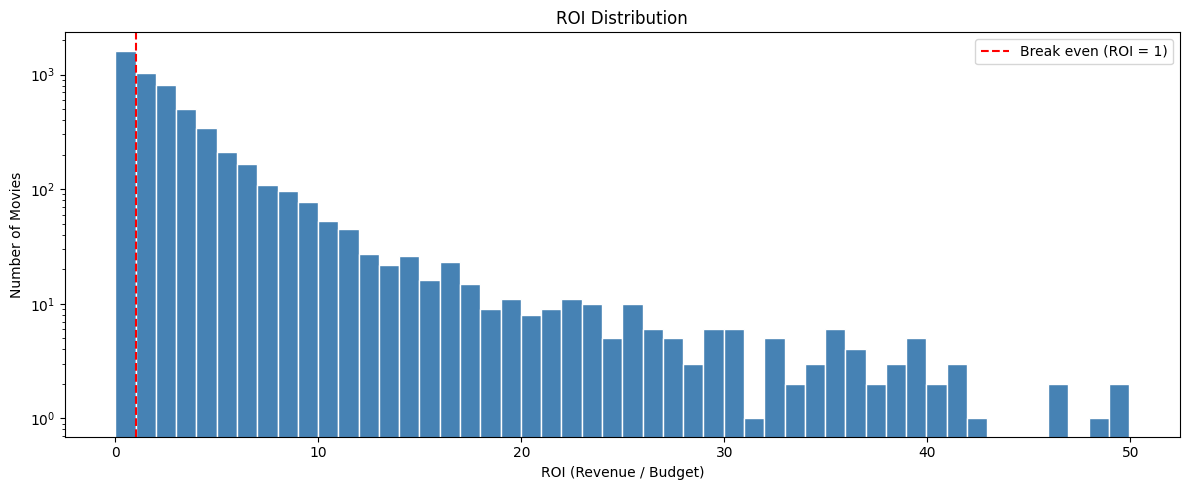

In [26]:
# Filter extreme outliers for readability
roi_filtered = movies_financial[movies_financial['roi'] < 50]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(roi_filtered['roi'], bins=50, color='steelblue', edgecolor='white')
ax.set_yscale('log')
ax.axvline(x=1, color='red', linestyle='--', linewidth=1.5, label='Break even (ROI = 1)')
ax.set_title('ROI Distribution')
ax.set_xlabel('ROI (Revenue / Budget)')
ax.set_ylabel('Number of Movies')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'roi_distribution.png', dpi=150)
plt.show()

## Section 5 — Ratings Analysis

### 5.1 Rating Distribution


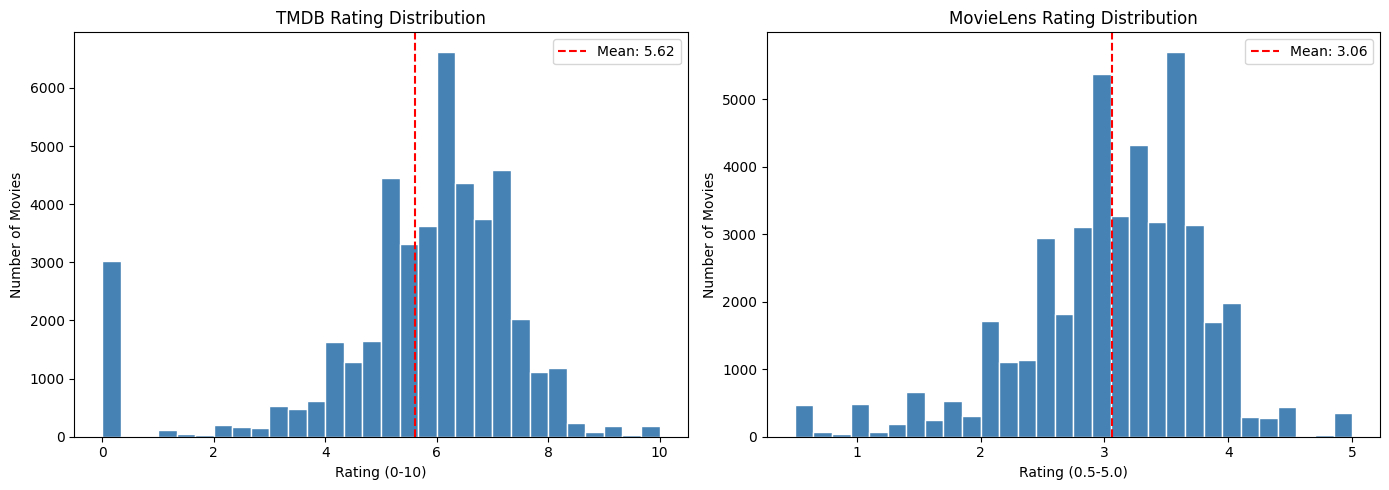

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TMDB ratings
axes[0].hist(movies['vote_average'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(movies['vote_average'].mean(), color='red', linestyle='--',
                label=f"Mean: {movies['vote_average'].mean():.2f}")
axes[0].set_title('TMDB Rating Distribution')
axes[0].set_xlabel('Rating (0-10)')
axes[0].set_ylabel('Number of Movies')
axes[0].legend()

# MovieLens ratings
axes[1].hist(movies['movielens_avg_rating'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(movies['movielens_avg_rating'].mean(), color='red', linestyle='--',
                label=f"Mean: {movies['movielens_avg_rating'].mean():.2f}")
axes[1].set_title('MovieLens Rating Distribution')
axes[1].set_xlabel('Rating (0.5-5.0)')
axes[1].set_ylabel('Number of Movies')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'rating_distribution.png', dpi=150)
plt.show()

### 5.2 Genre vs Average Rating


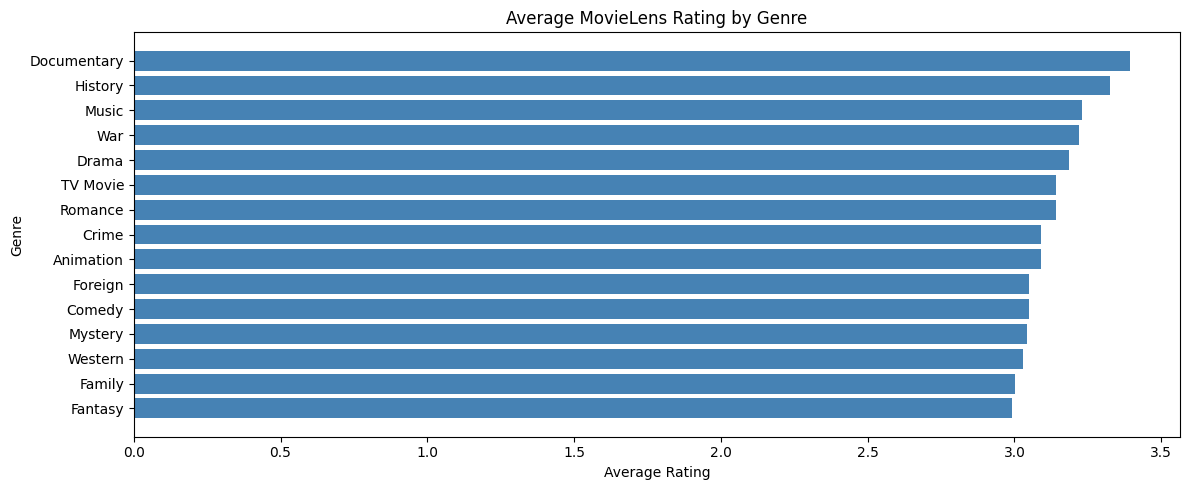

In [15]:
rows = []
for _, row in movies.dropna(subset=['movielens_avg_rating']).iterrows():
    for genre in row['genres_list']:
        rows.append({'genre': genre, 'rating': row['movielens_avg_rating']})

genre_ratings = pd.DataFrame(rows)
genre_avg = genre_ratings.groupby('genre')['rating'].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(genre_avg.index[::-1], genre_avg.values[::-1], color='steelblue')
ax.set_title('Average MovieLens Rating by Genre')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'genre_vs_rating.png', dpi=150)
plt.show()